- 실습 기본 환경 설정


In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED, deterministic=True)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 8-3 깊이의 한계를 극복하는 덧셈의 마법, ResNet

본 노트북은 본문 8-3절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 배치 정규화의 부작용을 확인하는 실험([표 8-5], [표 8-6], [그림 8-4])
- 잔차 학습을 담당하는 `ResidualBlock` 클래스와 이를 사용한 `MiniResNet` 모델
- `MiniVGGNetBN`과의 학습 및 평가 결과 비교([표 8-7])
- 더 깊은 신경망에서 잔차 학습의 효과([그림 8-6])

> 8장 코드 예제의 텐서 형태를 보여 주는 주석에는 배치 차원이 생략되어 있다.

## 배치 정규화의 부작용

- 본문은 이 실험 코드를 싣지 않았지만, 훅을 등록하거나 모델에 속한 계층과 블록의 정보를 확인하는 데 도움이 되는 내용이 포함되어 있다.
- 합성곱 계층과 배치 정규화 계층의 조합을 각각 12개, 48개, 96개 쌓은 세 모델을 만들어 비교한다.
    - 배치 정규화의 부작용을 확인하는 것이 목적이며, 성능이 좋은 모델을 만드는 것이 아니다.

In [2]:
# 참고 - 배치 정규화의 부작용을 실험하기 위한 모델
import torch.nn as nn

# 배치 정규화를 num_blocks회 반복하는 단순한 합성곱 모델
#   배치 정규화의 부작용을 확인하는 것이 목적이며, 특정 작업에 성능이 좋은 모델을 만드는 것이 아님
class StackedConvBN(nn.Module):
    def __init__(self, num_blocks, channels=16):
        super().__init__()
        # 첫 합성곱으로 채널 수를 channels로 맞춤
        layers = [
            nn.Conv2d(3, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
        ]

        # 이후 num_blocks - 1회 반복해 동일 채널 합성곱 + 배치 정규화 블록 추가
        for _ in range(num_blocks - 1):
            layers.append(
                nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            )
            layers.append(nn.BatchNorm2d(channels))
            layers.append(nn.ReLU())
        self.features = nn.Sequential(*layers)

    def forward(self, x):
        return self.features(x)

- 값이 같은 두 텐서와, 소수점 다섯째 자리 밑만 다른 두 텐서를 각각 입력해 출력을 비교한다.
    - 두 입력을 하나의 배치로 묶어 모델에 넣으면, 배치 단위 통계를 사용하는 배치 정규화가 학습에서 배치마다 입력이 달라지는 상황과 같은 조건이 된다.

In [3]:
# 참고 - 두 입력에 대한 모델 출력의 유클리드 거리와 코사인 유사도([표 8-5]와 [표 8-6])

import torch
import torch.nn.functional as F

@torch.no_grad()
# 두 입력 텐서에 대한 모델 출력의 유클리드 거리와 코사인 유사도를 계산하는 함수
def measure_similarity(model, x_a, x_b):
    model.train()
    # 두 입력 텐서를 묶어서 마치 하나의 배치인 것 처럼 모델에 입력
    #   배치 정규화는 배치 단위 통계를 사용해 정규화하므로, 
    #   학습에서 배치마다 입력이 달라지는 상황과 동일한 조건이 됨
    outputs = model(torch.cat([x_a, x_b], dim=0))
    # 입력에 대응되는 두 출력 텐서
    y_a = outputs[0].flatten()
    y_b = outputs[1].flatten()
    # 거리: 두 출력 텐서의 노름(유클리드 거리)
    dist = (y_a - y_b).norm().item()
    # 유사도: 코사인 유사도(F.cosine_similarity())를 사용해 계산
    cos = F.cosine_similarity(y_a.unsqueeze(0), y_b.unsqueeze(0)).item()
    return dist, cos

torch.manual_seed(SEED)

# 무작위로 생성한 3개의 텐서
#   test_input: 무작위 생성 텐서
#   same_input: test_input을 복사한 값이 동일한 텐서
#   similar_input: test_input에 소수점 다섯째 자리 밑만 다른 무작위 텐서를 더한 거의 동일한 텐서
test_input = torch.randn(1, 3, 32, 32)
same_input = test_input.clone()                 # test_input을 복사해 값이 같은 텐서 생성
# 소수점 다섯째 자리 밑만 다른 입력
similar_input = test_input + 1e-5 * torch.randn_like(test_input)

# 세 모델 생성 (같은 초기 가중치)
torch.manual_seed(SEED)
conv_12 = StackedConvBN(12)                     # 12-Conv 모델(12개의 합성곱 계층 포함)
torch.manual_seed(SEED)
conv_48 = StackedConvBN(48)                     # 48-Conv 모델
torch.manual_seed(SEED)
conv_96 = StackedConvBN(96)                     # 96-Conv 모델
models = [conv_12, conv_48, conv_96]


def print_similarity_table(title, x_b):
    print(title)
    print(f'{"":>14s} | {"12-Conv":>10s} | {"48-Conv":>10s} | {"96-Conv":>10s}')
    print('-' * 55)
    results = [measure_similarity(m, test_input, x_b) for m in models]
    print(f'{"유클리드 거리":>8s} | ' + ' | '.join(f'{d:>10.6f}' for d, _ in results))
    print(f'{"코사인 유사도":>8s} | ' + ' | '.join(f'{c:>10.6f}' for _, c in results))

# test_input과 same_input을 입력했을 때의 결과(값이 같은 두 텐서)
print_similarity_table('값이 같은 두 텐서에 대한 출력 텐서의 모델별 유사도', same_input)
print()
# test_input과 similar_input을 입력했을 때의 결과(값이 같은 것이나 다름 없는 두 텐서)
print_similarity_table('값이 거의 같은 두 텐서에 대한 출력 텐서의 모델별 유사도', similar_input)

값이 같은 두 텐서에 대한 출력 텐서의 모델별 유사도
               |    12-Conv |    48-Conv |    96-Conv
-------------------------------------------------------
 유클리드 거리 |   0.000000 |   0.000000 |   0.000000
 코사인 유사도 |   1.000000 |   1.000000 |   1.000000

값이 거의 같은 두 텐서에 대한 출력 텐서의 모델별 유사도
               |    12-Conv |    48-Conv |    96-Conv
-------------------------------------------------------
 유클리드 거리 |   0.007275 |   3.609047 | 100.194923
 코사인 유사도 |   1.000000 |   0.999205 |   0.400111


- 값이 같은 입력([표 8-5])은 유클리드 거리 0, 코사인 유사도 1로 출력도 같다.
- 값이 거의 같은 입력([표 8-6])에서는 결과가 달라진다.

| | 12 합성곱 모델 | 48 합성곱 모델 | 96 합성곱 모델 |
|---|---|---|---|
| 유클리드 거리 | 0.007085 | 3.837144 | 100.281090 |
| 코사인 유사도 | 1.000000 | 0.999103 | 0.389655 |

- 모델이 깊어질수록 유클리드 거리가 폭발적으로 커진다. 입력의 미세한 차이가 출력에서 그만큼 증폭된다는 뜻이다.
    - 96 합성곱 모델은 코사인 유사도마저 0.389655로 떨어진다. 두 출력 벡터 사이의 각이 약 67도나 벌어져 크기뿐 아니라 방향까지 어긋났다는 의미다.

## 합성곱 계층별 기울기 유사도([그림 8-4])

- 훅을 사용하면 모든 합성곱 계층에서 계산한 기울기를 확인할 수 있다.
    - 비슷한 두 입력으로 계산된 기울기를 계층별 코사인 유사도로 비교한다. 1에 가까울수록 기울기의 방향이 비슷하다.

In [4]:
# 참고 - 배치 정규화 모델의 합성곱 계층별 기울기 코사인 유사도 측정([그림 8-4])
import numpy as np

# 두 입력에 대한 합성곱 계층별 기울기의 유사도를 계산하는 함수
def layer_grad_cosines(model, x_a, x_b):
    conv_layers = [m for m in model.modules()
                   if isinstance(m, nn.Conv2d)]


    def grads_for_input(x):
        for layer in conv_layers:
            layer.weight.grad = None
        out = model(x)
        # 전역 평균 풀링 후 합을 손실로 삼아 합성곱 기울기를 구함
        loss = F.adaptive_avg_pool2d(out, 1).flatten().sum()
        loss.backward()
        # 반환값: 합성곱 계층별 합산 기울기의 리스트
        return [layer.weight.grad.flatten().clone()
                for layer in conv_layers]

    model.train()
    # 두 입력에 대한 합성곱 계층별 기울기 계산
    grads_a = grads_for_input(x_a)
    grads_b = grads_for_input(x_b)
    # 계층별 기울기의 코사인 유사도 리스트를 반환
    #   앞 부분이 입력에 가까운 합성곱 계층, 뒷 부분이 출력에 가까운 합성곱 계층
    return [
        F.cosine_similarity(ga.unsqueeze(0), gb.unsqueeze(0)).item()
        for ga, gb in zip(grads_a, grads_b)
    ]

# 무작위 파라미터로 초기화된 12, 48, 96 합성곱 모델 재생성(기울기도 초기화)
torch.manual_seed(SEED)
conv_12 = StackedConvBN(12)
torch.manual_seed(SEED)
conv_48 = StackedConvBN(48)
torch.manual_seed(SEED)
conv_96 = StackedConvBN(96)

cos_12 = layer_grad_cosines(conv_12, test_input, similar_input)
cos_48 = layer_grad_cosines(conv_48, test_input, similar_input)
cos_96 = layer_grad_cosines(conv_96, test_input, similar_input)

print(f'12 합성곱: 코사인 평균 {np.mean(cos_12):.6f}, '
      f'최저 {min(cos_12):.6f}')
print(f'48 합성곱: 코사인 평균 {np.mean(cos_48):.6f}, '
      f'최저 {min(cos_48):.6f}')
print(f'96 합성곱: 코사인 평균 {np.mean(cos_96):.6f}, '
      f'최저 {min(cos_96):.6f}')

12 합성곱: 코사인 평균 0.999768, 최저 0.999664
48 합성곱: 코사인 평균 0.923123, 최저 0.898683
96 합성곱: 코사인 평균 0.063293, 최저 -0.133780


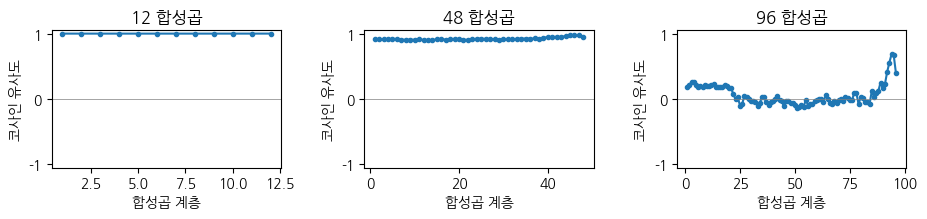

In [5]:
# 참고 - 합성곱 계층별 기울기 유사도 그래프([그림 8-4])
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.3))
for ax, name, cos in [
    (axes[0], '12 합성곱', cos_12),
    (axes[1], '48 합성곱', cos_48),
    (axes[2], '96 합성곱', cos_96),
]:
    ax.plot(range(1, len(cos) + 1), cos, '-o', markersize=3)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('합성곱 계층')
    ax.set_ylabel('코사인 유사도')
    ax.set_title(name)
    ax.set_ylim(-1.05, 1.05)
plt.tight_layout()
plt.show()

- 12 합성곱 모델은 이 정도 입력 차이로는 거의 흔들리지 않는다.
- 48 합성곱 모델부터 살짝 흔들리기 시작해, 96 합성곱 모델은 출력층 근처의 몇 개 계층을 빼면 코사인 유사도가 0.2 아래로 주저앉는다.
    - 중간 계층에서는 0 근처까지 내려가고, 일부 계층은 0 아래로 떨어져 기울기가 아예 반대 방향을 가리킨다.
- 배치 정규화는 입력 텐서의 통계량으로 정규화하므로 입력이 조금만 달라도 정규화 결과에 작은 차이가 생기고, 계층이 늘어날수록 이 차이가 쌓여 큰 차이로 벌어진다. 일종의 정보 왜곡이다.

## 잔차 블록

- 잔차 블록은 차이를 학습하는 주 경로(`main_path`)와 입력을 그대로 전달하는 지름길 경로(`shortcut`)로 나뉜다.
- 주 경로는 두 개의 합성곱 계층을 포함한다.
    - 합성곱 계층 하나마다 지름길 경로가 있으면 잔차가 지나치게 단순해져 선형 함수가 된다. 그래서 합성곱 계층 두 개를 비선형 활성화 함수와 함께 사용해 조금 더 복잡한 잔차를 만든다.
- 지름길 경로는 아무 연산도 하지 않는 통로이므로 항등 계층(`nn.Identity`)을 배치한다.
    - 다만 주 경로에서 채널의 수가 바뀌면 텐서의 모양이 달라져 두 경로의 결과를 합칠 수 없다. 이때만 예외적으로 1x1 합성곱 계층을 어댑터로 사용한다.
    - 이 합성곱 어댑터는 인접 픽셀의 정보를 결합하지 않고, 주 경로의 결과와 채널 수만 맞추는 방법을 학습한다.

In [6]:
# 참고 - CIFAR-10 데이터로더(8-1절 ~ 8-3절 공통)

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# data_root: 데이터셋 다운로드 경로
data_root = '../../download'

# 데이터 변환 객체
CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)

# 검증, 평가 데이터셋 데이터 변환 객체 (증강 없음)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 훈련 데이터셋 데이터 변환 객체 (증강 추가)
train_transform = transforms.Compose([
    # 4 픽셀 패딩 후 32x32 크기로 무작위 자르기
    transforms.RandomCrop(32, padding=4),
    # 50% 확률로 좌우 반전
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 데이터셋 생성
TRAIN_SIZE, VALID_SIZE = 40000, 10000       # 훈련/검증 데이터셋의 크기

# 같은 데이터셋으로 증강 변환 적용/미적용 데이터셋을 생성

# 증강 변환 적용: 훈련용으로 사용
train_full = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=train_transform
    #download=True, transform=transform
)
# 증강 변환 미적용: 검증, 평가용으로 사용
valid_full = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=transform,
)

test_set = datasets.CIFAR10(
    root=data_root, train=False,
    download=True, transform=transform,
)

# 같은 기준으로 train_full과 valid_full을 분할해 훈련 데이터셋과 검증 데이터셋 생성
train_set, _ = random_split(train_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))
# train_evaluate_set: 평가 시에는 증강 변환을 하지 않은 데이터셋 적용이 필요
train_evaluate_set, valid_set = random_split(valid_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))
#train_set, valid_set = random_split(valid_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))
# 배치 크기 128인 데이터로더 생성
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
train_evaluate_loader = DataLoader(train_evaluate_set, batch_size=BATCH_SIZE, shuffle=False)
#train_evaluate_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=False)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
######################################################################################
# 코드 8-5 - 잔차 블록을 정의하는 ResidualBlock 클래스
######################################################################################

# 주 경로: 합성곱 -> 배치 정규화 -> ReLU 활성화 -> 합성곱 -> 배치 정규화
# 지름길 경로: 항등 함수(nn.Identity()는 값을 건드리지 않고 그대로 통과시킴)
# 데이터의 채널 수가 바뀌는 경우에만 이를 조절하는 합성곱 -> 배치 정규화 계층 추가
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # 주 경로: x를 입력받아 잔차(학습 결과로 y-x에 수렴)를 출력
        self.main_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )                                # (in_channels, ...) -> (out_channels, ...)
        # 지름길 경로: 입력을 그대로 전달하는 항등 함수 계층(nn.Identity)
        self.shortcut = nn.Identity()    # (in_channels, ...) -> (in_channels, ...)
        # 어댑터: 주 경로를 통과하면서 데이터의 채널 수가 바뀌는 경우
        #         주 경로 결과와 더할 수 있도록 지름길의 입력 데이터 형태를 맞춰 줘야 함
        #         1x1 필터의 합성곱과 배치 정규화 계층을 사용(형태를 맞추는 방법만 학습)
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )                            # (in_channels, ...) -> (out_channels, ...)
        # 최종 출력에 적용할 활성화 함수
        self.activation = nn.ReLU()

    def forward(self, x):
        # 주 경로의 출력(y-x에 수렴)과 지름길 경로의 출력(x)을 더해 y에 근접한 출력 생성
        out = self.main_path(x) + self.shortcut(x)
        # 더한 후 활성화 계층 적용
        out = self.activation(out)
        return out

## MiniResNet 모델

- `MiniResNet`은 `MiniVGGNetBN`보다 합성곱 계층의 수가 늘어났지만, 지름길 경로를 가진 잔차 블록을 적용해 손실 기울기를 잘 전달할 수 있도록 설계했다.
    - 잔차 블록 다섯 개의 지름길 경로 중 두 개는 항등 함수를 통해, 세 개는 어댑터를 통해 입력을 전달한다.
- 분류기 앞에 `nn.AdaptiveAvgPool2d((1, 1))`을 배치했다.
    - 이 클래스는 입력 데이터의 크기가 변하더라도 지정한 출력 크기에 맞춰 풀링에 사용할 필터 크기와 스트라이드를 자동으로 계산한다.
    - 출력 크기를 `(1, 1)`로 지정하면 채널마다 전체 값을 평균 내 하나의 값으로 압축한다. 이런 방식의 풀링을 전역 평균 풀링이라고 한다.
    - `(128, 4, 4)` 텐서를 평탄화한 2,048개의 입력을 처리하려고 파라미터가 2만여 개인 선형 계층을 두는 대신, 학습 파라미터가 없는 풀링 계층을 사용하면 모델이 가벼워지고 과적합 위험도 줄어든다.

In [8]:
######################################################################################
# 코드 8-6 - 잔차 블록을 사용해 만든 MiniResNet 클래스
######################################################################################

# (잔차 블록) * 2 -> 최대 풀링 -> (잔차 블록) * 2 -> 최대 풀링 ->
#    -> 잔차 블록 -> 전역 평균 풀링 계층 -> 완전 연결 계층(분류기)
# 연속된 2개의 잔차 블록 중
#    첫 번째 잔차 블록은 채널 수 변경: 어댑터를 지름길 경로로 사용
#    두 번째 잔차 블록은 채널 수 유지: 항등 함수를 지름길 경로로 사용
class MiniResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 잔차 계층 블록을 사용하는 특징 추출기
        self.features = nn.Sequential(
            ResidualBlock(3, 32),                   # (3, 32, 32) -> (32, 32, 32)
            ResidualBlock(32, 32),                  #             -> (32, 32, 32)
            nn.MaxPool2d(kernel_size=2, stride=2),  #             -> (32, 16, 16)
            ResidualBlock(32, 64),                  #             -> (64, 16, 16)
            ResidualBlock(64, 64),                  #             -> (64, 16, 16)
            nn.MaxPool2d(kernel_size=2, stride=2),  #             -> (64, 8, 8)
            ResidualBlock(64, 128),                 #             -> (128, 8, 8)
            nn.MaxPool2d(kernel_size=2, stride=2),  #             -> (128, 4, 4)
        )
        # 전역 평균 풀링
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))
        # 분류기
        self.classifier = nn.Sequential(
            nn.Flatten(),                           #             -> (128,)
            nn.Linear(128, num_classes)             #             -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pooling(x)
        x = self.classifier(x)
        return x

In [9]:
# 참고 - MiniResNet 모델의 구조 정보
import torchinfo

print(torchinfo.summary(MiniResNet(), input_size=(64, 3, 32, 32), device='cpu'))

Layer (type:depth-idx)                   Output Shape              Param #
MiniResNet                               [64, 10]                  --
├─Sequential: 1-1                        [64, 128, 4, 4]           --
│    └─ResidualBlock: 2-1                [64, 32, 32, 32]          --
│    │    └─Sequential: 3-1              [64, 32, 32, 32]          10,208
│    │    └─Sequential: 3-2              [64, 32, 32, 32]          160
│    │    └─ReLU: 3-3                    [64, 32, 32, 32]          --
│    └─ResidualBlock: 2-2                [64, 32, 32, 32]          --
│    │    └─Sequential: 3-4              [64, 32, 32, 32]          18,560
│    │    └─Identity: 3-5                [64, 32, 32, 32]          --
│    │    └─ReLU: 3-6                    [64, 32, 32, 32]          --
│    └─MaxPool2d: 2-3                    [64, 32, 16, 16]          --
│    └─ResidualBlock: 2-4                [64, 64, 16, 16]          --
│    │    └─Sequential: 3-7              [64, 64, 16, 16]          55,552
│ 

## 모델의 학습과 평가([표 8-7])

- 학습 함수와 학습 설정은 8-1절, 8-2절과 같다.

In [10]:
# 참고 - 모델 학습에 사용하는 함수(8-1절 ~ 8-3절 공통 사용)
import copy

# 1 에포크 학습 함수
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 손실과 정확도를 반환하는 검증 함수
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size

# 조기 종료 방식으로 모델을 학습하는 학습 함수
def train_with_early_stopping(model, train_loader, valid_loader,
                              criterion, optimizer, epochs, patience,
                              device):
    model.to(device)
    # 학습 로거 설정
    log = common.EpochLogger(epochs, target_rows=epochs)
    # 조기 종료 판단을 위한 변수 초기화
    best_valid_loss = float('inf')
    best_epoch = -1
    best_model_params = None
    patience_counter = 0
    # 학습 루프
    for epoch in range(1, epochs + 1):
        # 최적화
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        # 검증
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)
        # 학습 로그 저장 및 출력(정확도는 백분율로 저장)
        log.row(epoch, train_loss, valid_loss, valid_acc * 100)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            best_model_params = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    # 최소 검증 손실 시점의 파라미터로 모델 복원
    if best_model_params is not None:
        print(f'최적 에포크({best_epoch}, 최소 검증 손실 {best_valid_loss:.4f})의 파라미터로 모델 복원')
        model.load_state_dict(best_model_params)    
    return log

In [11]:
# 참고 - 학습 설정
EPOCHS = 200
PATIENCE = 10
LR = 1e-3
criterion = nn.CrossEntropyLoss()

MiniResNet 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.3472       1.2618       57.50%     0:15


  2/200       0.9136       1.1585       62.59%     0:29


  3/200       0.7509       0.9663       68.42%     0:44


  4/200       0.6513       0.8500       72.13%     0:59


...

 40/200       0.1438       0.4786       86.86%    10:19


 41/200       0.1372       0.4197       88.40%    10:36


 42/200       0.1336       0.4721       86.87%    10:52


 43/200       0.1338       0.4758       87.16%    11:08


 44/200       0.1276       0.4185       88.79%    11:28
최적 에포크(34, 최소 검증 손실 0.3955)의 파라미터로 모델 복원


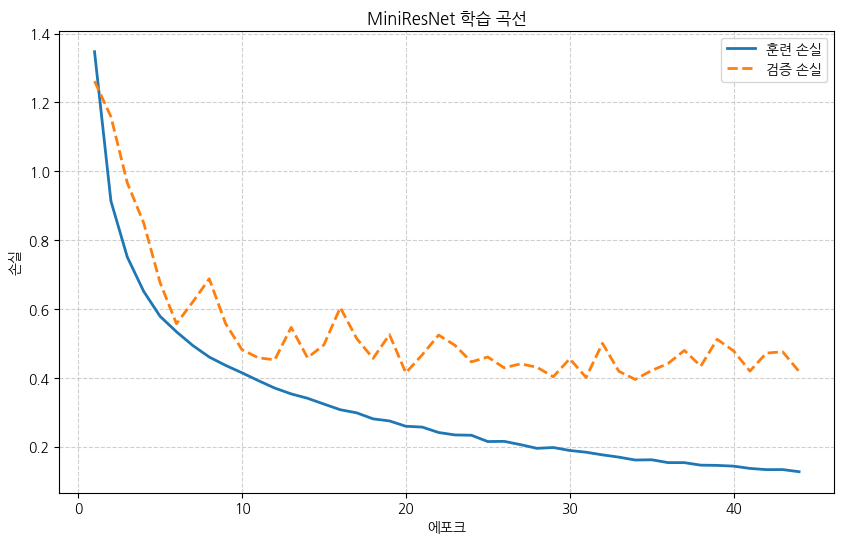

In [12]:
# 참고 - MiniResNet 학습
import torch.optim as optim

# 모델마다 결과 재현을 위해 학습 전에 시드 고정
common.set_seed(SEED, deterministic=True)

# MiniResNet 모델 객체를 생성하고 학습 장치로 이동
model_resnet = MiniResNet()
model_resnet.to(device)                               

# 옵티마이저
optimizer = optim.Adam(model_resnet.parameters(), lr=LR)

# 모델 학습
print('MiniResNet 학습')
log_resnet = train_with_early_stopping(
    model_resnet, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device
)

log_resnet.plot(title='MiniResNet 학습 곡선', y_label='손실')

# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

# model_resnet = MiniResNet()
# model_resnet.to(device)
# optimizer = optim.Adam(model_resnet.parameters(), lr=LR)

# print('=== MiniResNet 학습 ===')
# log_resnet = train_with_early_stopping(
#     model_resnet, train_loader, valid_loader, criterion, optimizer,
#     EPOCHS, PATIENCE, device,
# )
# log_resnet.plot(title='MiniResNet 학습 곡선', y_label='손실')

# result_resnet = collect_result('MiniResNet', model_resnet, log_resnet)

In [13]:
# 참고 - MiniResNet 모델의 평가

train_loss, train_acc = evaluate(model_resnet, train_evaluate_loader, criterion, device)
test_loss, test_acc = evaluate(model_resnet, test_loader, criterion, device)
print('MiniResNet 모델 평가(훈련 데이터셋)')
print(f'훈련 손실: {train_loss:.4f}, 정확도: {train_acc * 100:.2f}%')
print(f'MiniResNet 모델 평가(평가 데이터셋)')
print(f'평가 손실: {test_loss:.4f}, 정확도: {test_acc * 100:.2f}%')

MiniResNet 모델 평가(훈련 데이터셋)
훈련 손실: 0.1545, 정확도: 94.40%
MiniResNet 모델 평가(평가 데이터셋)
평가 손실: 0.4580, 정확도: 86.94%


- 본문 [표 8-7]의 수치(MiniVGGNetBN 29 에포크 / 93.19% / 86.27%, MiniResNet 27 에포크 / 93.44% / 86.68%)와 비교해 보자.
- `MiniVGGNetBN`보다 분류 정확도는 좋아졌지만 차이는 크지 않다.
    - 잔차 학습은 훨씬 더 깊은 신경망에서 진가가 드러나는데, CIFAR-10 데이터셋은 합성곱 계층의 수를 늘린 더 깊은 신경망에 적용하기에는 적합하지 않다.
    - 다만 지름길 경로를 더했어도 에포크당 학습 시간과 전체 학습 시간에 큰 차이가 없음을 확인할 수 있다.

## 더 깊은 신경망에서 잔차 학습의 효과([그림 8-6])

- 주 경로에 각각 12개, 96개, 384개의 합성곱 계층을 둔 잔차 학습 모델에서 계층별 기울기 유사도를 구한다.
    - [그림 8-4]와 같은 실험을 잔차 학습 모델로 반복 수행하는 것이다.

In [14]:
# 참고 - 잔차 학습으로 개선된 결과를 확인하는 실험을 위한 모델

# num_convs개의 합성곱 계층을 반복하는 단순한 잔차 학습 모델
class StackedResBlock(nn.Module):
    def __init__(self, num_convs, channels=16):
        super().__init__()
        layers = [
            nn.Conv2d(3, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
        ]
        # 각 잔차 블록이 합성곱 2개를 포함하므로 잔차 블록은 절반을 사용
        num_res_blocks = (num_convs - 1) // 2
        for _ in range(num_res_blocks):
            layers.append(ResidualBlock(channels, channels))
        self.features = nn.Sequential(*layers)

    def forward(self, x):
        return self.features(x)

In [15]:
# 참고 - 잔차 모델의 합성곱 계층별 기울기 코사인 유사도
torch.manual_seed(SEED)
res_12 = StackedResBlock(num_convs=12)
torch.manual_seed(SEED)
res_96 = StackedResBlock(num_convs=96)
torch.manual_seed(SEED)
res_384 = StackedResBlock(num_convs=384)

cos_r12 = layer_grad_cosines(res_12, test_input, similar_input)
cos_r96 = layer_grad_cosines(res_96, test_input, similar_input)
cos_r384 = layer_grad_cosines(res_384, test_input, similar_input)

print(f'잔차 12 합성곱: 평균 {np.mean(cos_r12):.6f}, '
      f'최저 {min(cos_r12):.6f}')
print(f'잔차 96 합성곱: 평균 {np.mean(cos_r96):.6f}, '
      f'최저 {min(cos_r96):.6f}')
print(f'잔차 384 합성곱: 평균 {np.mean(cos_r384):.6f}, '
      f'최저 {min(cos_r384):.6f}')

잔차 12 합성곱: 평균 1.000000, 최저 1.000000
잔차 96 합성곱: 평균 0.999834, 최저 0.999613
잔차 384 합성곱: 평균 0.999835, 최저 0.999472


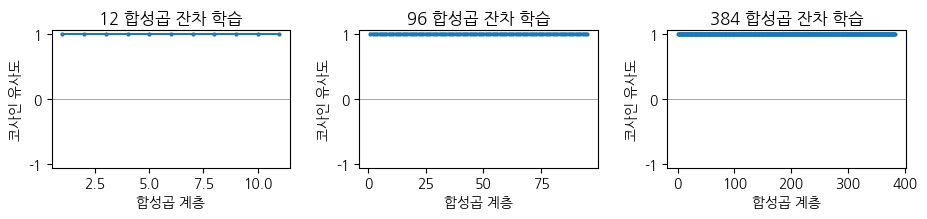

In [16]:
# 참고 - 잔차 학습 모델의 합성곱 계층별 기울기 유사도 그래프([그림 8-6])
fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.3))
for ax, name, cos in [
    (axes[0], '12 합성곱 잔차 학습', cos_r12),
    (axes[1], '96 합성곱 잔차 학습', cos_r96),
    (axes[2], '384 합성곱 잔차 학습', cos_r384),
]:
    ax.plot(range(1, len(cos) + 1), cos, '-o', markersize=2)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('합성곱 계층')
    ax.set_ylabel('코사인 유사도')
    ax.set_title(name)
    ax.set_ylim(-1.05, 1.05)
plt.tight_layout()
plt.show()

- [그림 8-4]에서 96 합성곱 모델은 기울기 방향이 무너졌지만, 같은 깊이의 잔차 학습 모델은 모든 계층에서 코사인 유사도가 1에 가깝게 유지된다.
    - 잔차 블록의 수에 비례해 배치 정규화 계층이 늘어났음에도, 심지어 384 합성곱 잔차 학습 모델에서도 마찬가지다.

## 정리

- 배치 정규화 계층이 많아지면 미세한 입력 차이가 누적되어 깊은 모델의 출력과 기울기 방향이 크게 흔들린다([표 8-6], [그림 8-4]).
- ResNet의 잔차 학습은 계층 블록이 입력과 출력의 차이(잔차)만 학습하고, 지름길 경로로 입력을 그대로 전달한다.
    - 순전파에서는 지름길로 온 변형 없는 입력과 합쳐지면서 왜곡이 억제된다.
    - 역전파에서는 지름길로 온 뒤 계층의 기울기와 합쳐져 앞 계층으로 전달되므로 전체 기울기가 소실되지 않는다.
- 전역 평균 풀링은 학습 파라미터 없이 특징 지도를 채널당 하나의 값으로 압축해, 모델을 가볍게 하고 과적합 위험을 줄인다.